In [1]:
!pip install lightgbm xgboost imbalanced-learn shap seaborn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Customer_Churn_Thesis"

RAW_DATA = f"{PROJECT_PATH}/data/raw/Churn_Modelling.csv"
PROCESSED_DATA = f"{PROJECT_PATH}/data/processed/Churn_Data_Augmented_Processed.csv"

RESULT_TABLES = f"{PROJECT_PATH}/results/tables"
RESULT_FIGURES = f"{PROJECT_PATH}/results/figures"

print(RAW_DATA)
print(PROCESSED_DATA)

/content/drive/MyDrive/Customer_Churn_Thesis/data/raw/Churn_Modelling.csv
/content/drive/MyDrive/Customer_Churn_Thesis/data/processed/Churn_Data_Augmented_Processed.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [5]:
df_raw = pd.read_csv(RAW_DATA)

print("Raw dataset shape:", df_raw.shape)

df_raw.head()

Raw dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
def feature_engineering(df):

    df = df.copy()

    df["Balance_Per_Product"] = df["Balance"] / df["NumOfProducts"]
    df["Tenure_Age_Ratio"] = df["Tenure"] / df["Age"]
    df["Is_Senior"] = (df["Age"] >= 60).astype(int)

    return df

In [7]:
def prepare_data(df):

    df = df.copy()

    df = pd.get_dummies(df, columns=["Geography","Gender"], drop_first=True)

    X = df.drop(["Exited","RowNumber","CustomerId","Surname"], axis=1)
    y = df["Exited"]

    return X,y

In [8]:
def evaluate_model(X_train, X_test, y_train, y_test):

    model = LGBMClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    return recall, precision, f1, auc

In [9]:
X,y = prepare_data(df_raw)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

recall_raw,precision_raw,f1_raw,auc_raw = evaluate_model(
    X_train,X_test,y_train,y_test
)

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


In [10]:
smote = SMOTE(random_state=42)

X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)

recall_smote,precision_smote,f1_smote,auc_smote = evaluate_model(
    X_train_sm,X_test,y_train_sm,y_test
)

[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001833 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [11]:
df_features = feature_engineering(df_raw)

X,y = prepare_data(df_features)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

recall_feat,precision_feat,f1_feat,auc_feat = evaluate_model(
    X_train,X_test,y_train,y_test
)

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003022 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1364
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


In [12]:
smote = SMOTE(random_state=42)

X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)

recall_final,precision_final,f1_final,auc_final = evaluate_model(
    X_train_sm,X_test,y_train_sm,y_test
)

[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [13]:
ablation_results = pd.DataFrame({

"Experiment":[
"Raw Data",
"Raw + SMOTE",
"Feature Engineering",
"Feature + SMOTE"
],

"Recall":[
recall_raw,
recall_smote,
recall_feat,
recall_final
],

"Precision":[
precision_raw,
precision_smote,
precision_feat,
precision_final
],

"F1":[
f1_raw,
f1_smote,
f1_feat,
f1_final
],

"AUC":[
auc_raw,
auc_smote,
auc_feat,
auc_final
]

})

print(ablation_results)

ablation_results.to_csv(
f"{RESULT_TABLES}/06_ablation_hybrid_threshold_colab_phase2_ablation_results.csv",
index=False
)

            Experiment    Recall  Precision        F1       AUC
0             Raw Data  0.491400   0.781250  0.603318  0.863255
1          Raw + SMOTE  0.658477   0.559499  0.604966  0.846804
2  Feature Engineering  0.471744   0.747082  0.578313  0.858819
3      Feature + SMOTE  0.633907   0.589041  0.610651  0.851790


In [14]:
df_processed = pd.read_csv(PROCESSED_DATA)

X = df_processed.drop("Exited",axis=1)
y = df_processed["Exited"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

smote = SMOTE(random_state=42)

X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)

In [15]:
base_models = [

("rf",RandomForestClassifier(
    n_estimators=300,
    random_state=42
)),

("xgb",XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss"
)),

("lgbm",LGBMClassifier(
    n_estimators=300
))

]

meta_model = LogisticRegression(max_iter=5000)

stack_model = StackingClassifier(

estimators=base_models,
final_estimator=meta_model,
cv=5,
passthrough=True

)

stack_model.fit(X_train_sm,y_train_sm)

y_pred = stack_model.predict(X_test)

print(classification_report(y_test,y_pred))

[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002962 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 5096, number of negative: 5096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1367
[LightGBM] [Info] Number of data points in the train set: 10192, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 5096, number of negative: 5096
[LightGBM] [Info] Auto-choosing col-wise multi-threading,

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1593
           1       0.89      0.87      0.88      1593

    accuracy                           0.88      3186
   macro avg       0.88      0.88      0.88      3186
weighted avg       0.88      0.88      0.88      3186



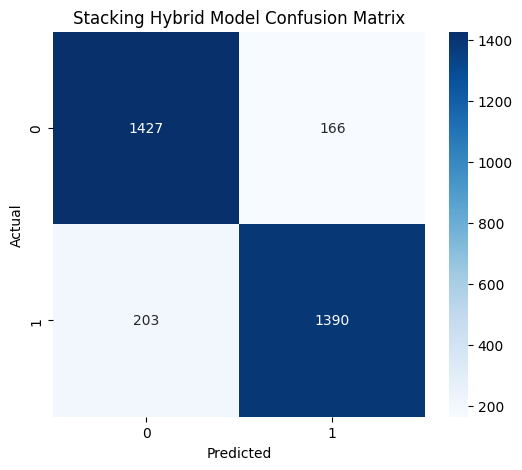

In [16]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Stacking Hybrid Model Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
f"{RESULT_FIGURES}/06_ablation_hybrid_threshold_colab_phase2_stacking_confusion_matrix.png"
)

plt.show()

In [17]:
y_prob = stack_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1,0.5,0.01)

recalls = []

for t in thresholds:

    preds = (y_prob>=t).astype(int)

    r = recall_score(y_test,preds)

    recalls.append(r)

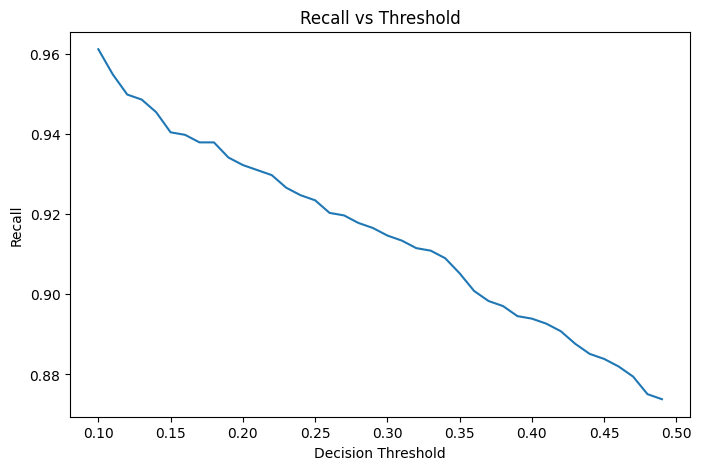

In [18]:
plt.figure(figsize=(8,5))

plt.plot(thresholds,recalls)

plt.xlabel("Decision Threshold")
plt.ylabel("Recall")

plt.title("Recall vs Threshold")

plt.savefig(
f"{RESULT_FIGURES}/06_ablation_hybrid_threshold_colab_phase2_threshold_recall_curve.png"
)

plt.show()

In [19]:
best_idx = np.argmax(recalls)

best_threshold = thresholds[best_idx]

print("Best Threshold:",best_threshold)
print("Best Recall:",recalls[best_idx])

Best Threshold: 0.1
Best Recall: 0.9610797237915882
